# EfficientNet-B0 WBC classifier — retraining with a proper validation split (v2)

**Why this notebook exists.** In the original notebook the *test* images were also used to choose the best epoch (the "Val Acc" column was computed on the test set), so the reported 99.44 % is optimistic. This version:

1. Splits PBC into **train 70 % / validation 10 % / test 20 %**, **stratified by class**, with sorted file lists so the split is reproducible.
2. Uses **exactly the same model and recipe** as before (EfficientNet-B0, 3-layer head with Dropout 0.3, Phase 1 frozen backbone → Phase 2 full fine-tune).
3. Chooses the checkpoint **on the validation set only** and evaluates on the test set **once**.
4. Adds the missing **uncertainty evaluation**: MC-Dropout (T = 20), expected calibration error (ECE), a reliability diagram, AUROC of uncertainty as an error detector, and accuracy per uncertainty level (LOW / MEDIUM / HIGH, same thresholds as `config.yaml`).

**Runtime:** Colab → *Runtime → Change runtime type → T4 GPU*. About 1 hour.
**Input:** the **PBC** single-cell dataset (Acevedo et al., 17,092 images in 8 class folders) in your Google Drive, as a folder or as the downloaded zip. The notebook searches your Drive for it automatically. *Not* TXL-PBC — that dataset has whole smear images with boxes and is only used for the YOLO detector. If you no longer have PBC: open https://data.mendeley.com/datasets/snkd93bnjr/1, click **Download All**, and upload the zip to My Drive.
**Output:** everything is saved to `MyDrive/thesis_effnet_v2/`.

In [1]:
SEED          = 42
DRIVE_DATA    = ''   # leave empty to search your Drive automatically, or give the folder / .zip path
#   This must be the PBC single-cell dataset (8 class folders: basophil, eosinophil, ...),
#   NOT TXL-PBC (whole smear images with boxes, used only for the YOLO detector).
OUT_DIR       = '/content/drive/MyDrive/thesis_effnet_v2'
IMG_SIZE      = 224
BATCH         = 32
P1_EPOCHS, P1_LR = 40, 1e-3     # Phase 1: frozen backbone (same as original)
P2_EPOCHS, P2_LR = 10, 1e-4     # Phase 2: full fine-tune (same as original)
PATIENCE      = 5
MC_PASSES     = 20
LOW_CONF, LOW_ENT = 0.85, 0.3   # uncertainty thresholds from config.yaml
MED_CONF, MED_ENT = 0.65, 0.6

## 1. Setup and data

In [2]:
!pip install -q timm
import os, json, time, random, shutil, glob
import numpy as np, cv2, torch, torch.nn as nn, torch.optim as optim, timm
import matplotlib.pyplot as plt, seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from google.colab import drive

drive.mount('/content/drive')
os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print('device:', DEVICE)

EXPECTED = {'basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet'}
def is_pbc(d):
    try: return EXPECTED <= {x.lower() for x in os.listdir(d) if os.path.isdir(os.path.join(d, x))}
    except Exception: return False

def find_pbc(root):
    for dirpath, dirnames, _ in os.walk(root):
        dirnames[:] = sorted(d for d in dirnames if d != '__MACOSX' and not d.startswith('.'))  # skip Mac metadata
        if dirpath.count(os.sep) - root.count(os.sep) > 4: dirnames[:] = []; continue
        if is_pbc(dirpath): return dirpath
    return None

src_path = DRIVE_DATA
if not src_path:
    print('Searching your Drive for the PBC dataset...')
    src_path = find_pbc('/content/drive/MyDrive')
    if src_path is None:  # maybe only the zip is there
        import glob
        zips = [z for z in glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True) if 'pbc' in os.path.basename(z).lower() and 'txl' not in os.path.basename(z).lower()]
        src_path = zips[0] if zips else None
assert src_path, ('PBC dataset not found in Drive. Download it from https://data.mendeley.com/datasets/snkd93bnjr/1 '
                  '(Download All), upload the zip to My Drive, and run again.')
print('Using:', src_path)

LOCAL_ROOT = '/content/pbc'
if not os.path.exists(LOCAL_ROOT):
    if src_path.lower().endswith('.zip'):
        import zipfile; print('Unzipping (a few minutes)...'); zipfile.ZipFile(src_path).extractall(LOCAL_ROOT)
        inner = [z for z in glob.glob(LOCAL_ROOT + '/**/*.zip', recursive=True)
                 if '__MACOSX' not in z and not os.path.basename(z).startswith('._')]   # Mendeley zip contains another zip
        for z in inner: zipfile.ZipFile(z).extractall(os.path.dirname(z))
    else:
        print('Copying from Drive (a few minutes)...'); shutil.copytree(src_path, LOCAL_ROOT)
LOCAL = find_pbc(LOCAL_ROOT)
assert LOCAL, 'Could not find the 8 class folders after copying/unzipping.'
CATEGORIES = sorted(d for d in os.listdir(LOCAL) if os.path.isdir(os.path.join(LOCAL, d)) and d.lower() in EXPECTED)
print('classes:', CATEGORIES)
assert len(CATEGORIES) == 8, 'expected the 8 PBC classes'

Mounted at /content/drive
device: cuda
Searching your Drive for the PBC dataset...
Using: /content/drive/MyDrive/PBC_dataset_normal_DIB.zip
Unzipping (a few minutes)...
classes: ['basophil', 'eosinophil', 'erythroblast', 'ig', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [3]:
# Sorted file lists -> the split is identical every time the notebook is run.
# Mac metadata files ('._*') and unreadable images are skipped and reported.
paths, labels = [], []
for k, cat in enumerate(CATEGORIES):
    for f in sorted(os.listdir(os.path.join(LOCAL, cat))):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._'):
            paths.append(os.path.join(LOCAL, cat, f)); labels.append(k)

X = np.zeros((len(paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
keep, bad = [], []
for i, p in enumerate(paths):
    img = cv2.imread(p)
    if img is None: bad.append(p); continue
    X[len(keep)] = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE)); keep.append(i)
X = X[:len(keep)]
paths, labels = np.array(paths)[keep], np.array(labels)[keep]
print(f'images loaded: {len(keep)}   skipped (unreadable): {len(bad)}', bad[:5])
print('per class:', {c: int((labels == k).sum()) for k, c in enumerate(CATEGORIES)})
assert len(keep) > 15000, 'far fewer images than the 17,092 in PBC - check the dataset folder'

idx = np.arange(len(labels))
idx_trval, idx_test = train_test_split(idx, test_size=0.20, stratify=labels, random_state=SEED)
idx_train, idx_val  = train_test_split(idx_trval, test_size=0.125, stratify=labels[idx_trval], random_state=SEED)  # 0.125*0.8 = 0.10
print(f'train {len(idx_train)} | val {len(idx_val)} | test {len(idx_test)}')
split = {'train': paths[idx_train].tolist(), 'val': paths[idx_val].tolist(), 'test': paths[idx_test].tolist()}
json.dump({k: [os.path.relpath(p, LOCAL) for p in v] for k, v in split.items()}, open(f'{OUT_DIR}/split.json', 'w'))
json.dump({'skipped_unreadable': [os.path.relpath(p, LOCAL) for p in bad]}, open(f'{OUT_DIR}/skipped_files.json', 'w'))

images loaded: 17092   skipped (unreadable): 1 ['/content/pbc/PBC_dataset_normal_DIB/neutrophil/.DS_169665.jpg']
per class: {'basophil': 1218, 'eosinophil': 3117, 'erythroblast': 1551, 'ig': 2895, 'lymphocyte': 1214, 'monocyte': 1420, 'neutrophil': 3329, 'platelet': 2348}
train 11963 | val 1710 | test 3419


In [4]:
norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
train_tf = transforms.Compose([transforms.ToPILImage(), transforms.RandomHorizontalFlip(0.5), transforms.RandomVerticalFlip(0.3),
                               transforms.RandomAffine(degrees=25, scale=(0.8, 1.2)),
                               transforms.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2), transforms.ToTensor(), norm])
eval_tf  = transforms.Compose([transforms.ToPILImage(), transforms.ToTensor(), norm])

class DS(Dataset):
    def __init__(s, ids, tf): s.ids, s.tf = ids, tf
    def __len__(s): return len(s.ids)
    def __getitem__(s, i): j = s.ids[i]; return s.tf(X[j]), int(labels[j])

g = torch.Generator().manual_seed(SEED)
train_dl = DataLoader(DS(idx_train, train_tf), batch_size=BATCH, shuffle=True, num_workers=2, generator=g)
val_dl   = DataLoader(DS(idx_val, eval_tf),   batch_size=64, num_workers=2)
test_dl  = DataLoader(DS(idx_test, eval_tf),  batch_size=64, num_workers=2)

## 2. Model (identical architecture to the original)

In [5]:
model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 1024), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(512, len(CATEGORIES)))
model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss()

def run_epoch(dl, train):
    model.train(train); tl = tc = n = 0
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb); loss = criterion(out, yb)
            if train: opt.zero_grad(); loss.backward(); opt.step()
            tl += loss.item() * len(yb); tc += (out.argmax(1) == yb).sum().item(); n += len(yb)
    return tl / n, 100 * tc / n

history = []
def train_phase(name, epochs, lr, params):
    global opt
    opt = optim.Adam(params, lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=3, factor=0.5)
    best, bad = -1, 0
    for ep in range(1, epochs + 1):
        t0 = time.time(); trl, tra = run_epoch(train_dl, True); vl, va = run_epoch(val_dl, False)
        sched.step(va); history.append({'phase': name, 'epoch': ep, 'train_loss': trl, 'train_acc': tra, 'val_loss': vl, 'val_acc': va})
        tag = ''
        if va > best: best, bad = va, 0; torch.save({'model_state': model.state_dict()}, '/content/best.pt'); tag = '  <- best (val)'
        else: bad += 1
        print(f'{name} ep {ep:2d}  train {trl:.4f}/{tra:.2f}%  val {vl:.4f}/{va:.2f}%  [{time.time()-t0:.0f}s]{tag}')
        if bad >= PATIENCE: print('early stop'); break
    model.load_state_dict(torch.load('/content/best.pt')['model_state'])
    return best

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

## 3. Training — checkpoint chosen on the **validation** set only

In [6]:
for p in model.parameters(): p.requires_grad = False
for p in model.classifier.parameters(): p.requires_grad = True
best1 = train_phase('P1', P1_EPOCHS, P1_LR, model.classifier.parameters())
for p in model.parameters(): p.requires_grad = True
best2 = train_phase('P2', P2_EPOCHS, P2_LR, model.parameters())
print(f'best validation accuracy: Phase 1 {best1:.2f}%  Phase 2 {best2:.2f}%')
torch.save({'model_state': model.state_dict(), 'classes': CATEGORIES, 'split': 'stratified 70/10/20, seed 42'},
           f'{OUT_DIR}/efficientnet_wbc_v2.pt')
json.dump(history, open(f'{OUT_DIR}/history.json', 'w'), indent=1)

P1 ep  1  train 0.9624/65.30%  val 0.7271/74.68%  [52s]  <- best (val)
P1 ep  2  train 0.6995/75.42%  val 0.6520/77.02%  [53s]  <- best (val)
P1 ep  3  train 0.6496/77.74%  val 0.6403/77.19%  [52s]  <- best (val)
P1 ep  4  train 0.6072/79.05%  val 0.6627/77.78%  [53s]  <- best (val)
P1 ep  5  train 0.5919/79.46%  val 0.5875/80.18%  [50s]  <- best (val)
P1 ep  6  train 0.5871/79.92%  val 0.5254/81.93%  [51s]  <- best (val)
P1 ep  7  train 0.5553/80.59%  val 0.6265/78.36%  [49s]
P1 ep  8  train 0.5533/80.40%  val 0.5422/80.76%  [49s]
P1 ep  9  train 0.5493/80.57%  val 0.4834/83.98%  [51s]  <- best (val)
P1 ep 10  train 0.5323/80.97%  val 0.4904/82.46%  [49s]
P1 ep 11  train 0.5268/81.76%  val 0.5033/83.39%  [50s]
P1 ep 12  train 0.5223/82.02%  val 0.4852/83.98%  [50s]
P1 ep 13  train 0.5113/82.63%  val 0.4909/83.10%  [49s]
P1 ep 14  train 0.4672/83.72%  val 0.4419/84.97%  [51s]  <- best (val)
P1 ep 15  train 0.4487/84.38%  val 0.4546/84.85%  [49s]
P1 ep 16  train 0.4487/84.35%  val 0.436

## 4. Single evaluation on the test set

TEST ACCURACY (deterministic): 98.60%   n = 3419
              precision    recall  f1-score   support

    basophil     0.9837    0.9877    0.9857       244
  eosinophil     1.0000    1.0000    1.0000       623
erythroblast     0.9968    0.9903    0.9935       310
          ig     0.9771    0.9585    0.9677       579
  lymphocyte     0.9958    0.9835    0.9896       243
    monocyte     0.9825    0.9894    0.9860       284
  neutrophil     0.9676    0.9850    0.9762       666
    platelet     0.9958    0.9979    0.9968       470

    accuracy                         0.9860      3419
   macro avg     0.9874    0.9866    0.9869      3419
weighted avg     0.9860    0.9860    0.9860      3419



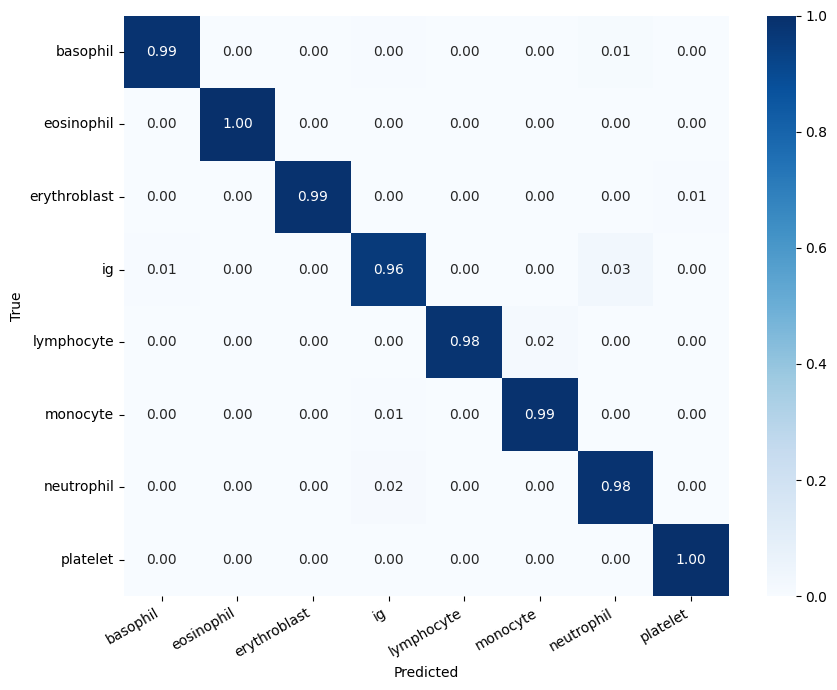

In [7]:
model.eval(); P, Y = [], []
with torch.no_grad():
    for xb, yb in test_dl: P.append(torch.softmax(model(xb.to(DEVICE)), 1).cpu()); Y.append(yb)
P1, Y = torch.cat(P).numpy(), torch.cat(Y).numpy()
pred1 = P1.argmax(1); acc1 = accuracy_score(Y, pred1)
print(f'TEST ACCURACY (deterministic): {100*acc1:.2f}%   n = {len(Y)}')
report = classification_report(Y, pred1, target_names=CATEGORIES, digits=4, output_dict=True)
print(classification_report(Y, pred1, target_names=CATEGORIES, digits=4))
cm = confusion_matrix(Y, pred1, normalize='true')
plt.figure(figsize=(9, 7)); sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/confusion_matrix_v2.png', dpi=200); plt.show()

## 5. MC-Dropout uncertainty and calibration

MC-Dropout accuracy: 98.57%   errors: 49
ECE  deterministic: 0.0039   MC-Dropout: 0.0032
AUROC of uncertainty as error detector: {'1 - confidence': np.float64(0.971), 'entropy': np.float64(0.97), 'variance': np.float64(0.968)}
per uncertainty level: {
 "LOW": {
  "n": 3255,
  "accuracy": 0.9972350230414746,
  "errors": 9
 },
 "MEDIUM": {
  "n": 98,
  "accuracy": 0.8469387755102041,
  "errors": 15
 },
 "HIGH": {
  "n": 66,
  "accuracy": 0.6212121212121212,
  "errors": 25
 }
}
share of all errors that are flagged HIGH: 25/49


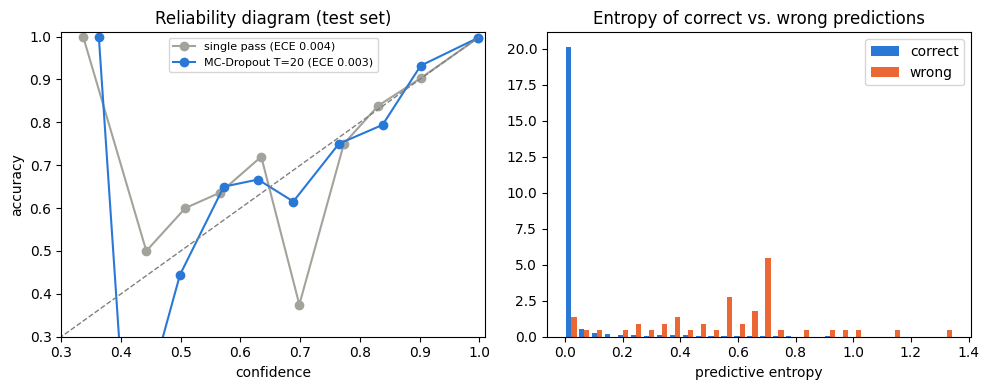

In [8]:
def enable_mc_dropout(m):
    m.eval()
    for mod in m.modules():
        if isinstance(mod, nn.Dropout): mod.train()   # same as src/classification/classifier.py

enable_mc_dropout(model); torch.manual_seed(SEED)
MC = []
with torch.no_grad():
    for xb, _ in test_dl:
        xb = xb.to(DEVICE)
        MC.append(torch.stack([torch.softmax(model(xb), 1) for _ in range(MC_PASSES)]).cpu())
MC = torch.cat(MC, 1).numpy()                     # (T, N, C)
pm = MC.mean(0); conf = pm.max(1); predm = pm.argmax(1)
ent = -(pm * np.log(pm + 1e-8)).sum(1); var = MC.var(0).mean(1)
correct = predm == Y
level = np.where((conf >= LOW_CONF) & (ent < LOW_ENT), 'LOW', np.where((conf >= MED_CONF) & (ent < MED_ENT), 'MEDIUM', 'HIGH'))

def ece(conf, correct, bins=15):
    edges = np.linspace(0, 1, bins + 1); e = 0; rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            e += m.mean() * abs(correct[m].mean() - conf[m].mean()); rows.append((conf[m].mean(), correct[m].mean(), m.sum()))
    return e, rows

ece_mc, rows_mc = ece(conf, correct); ece_det, rows_det = ece(P1.max(1), pred1 == Y)
n_err = int((~correct).sum())
auroc = {k: (roc_auc_score(~correct, s) if 0 < n_err < len(Y) else None)
         for k, s in {'1 - confidence': 1 - conf, 'entropy': ent, 'variance': var}.items()}
per_level = {L: {'n': int((level == L).sum()), 'accuracy': float(correct[level == L].mean()) if (level == L).any() else None,
                 'errors': int((~correct[level == L]).sum())} for L in ['LOW', 'MEDIUM', 'HIGH']}
print(f'MC-Dropout accuracy: {100*correct.mean():.2f}%   errors: {n_err}')
print(f'ECE  deterministic: {ece_det:.4f}   MC-Dropout: {ece_mc:.4f}')
print('AUROC of uncertainty as error detector:', {k: (round(v, 3) if v else v) for k, v in auroc.items()})
print('per uncertainty level:', json.dumps(per_level, indent=1))
print(f'share of all errors that are flagged HIGH: {per_level["HIGH"]["errors"]}/{n_err}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for rows, lab, c in [(rows_det, f'single pass (ECE {ece_det:.3f})', '#a3a39c'), (rows_mc, f'MC-Dropout T=20 (ECE {ece_mc:.3f})', '#2a78d6')]:
    ax[0].plot([r[0] for r in rows], [r[1] for r in rows], 'o-', color=c, label=lab)
ax[0].plot([0, 1], [0, 1], '--', color='grey', lw=1); ax[0].set_xlabel('confidence'); ax[0].set_ylabel('accuracy')
ax[0].set_title('Reliability diagram (test set)'); ax[0].legend(fontsize=8); ax[0].set_xlim(0.3, 1.01); ax[0].set_ylim(0.3, 1.01)
ax[1].hist([ent[correct], ent[~correct]], bins=30, label=['correct', 'wrong'], color=['#2a78d6', '#eb6834'], density=True)
ax[1].set_xlabel('predictive entropy'); ax[1].set_title('Entropy of correct vs. wrong predictions'); ax[1].legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/calibration_v2.png', dpi=200); plt.show()

## 6. Training curves and summary

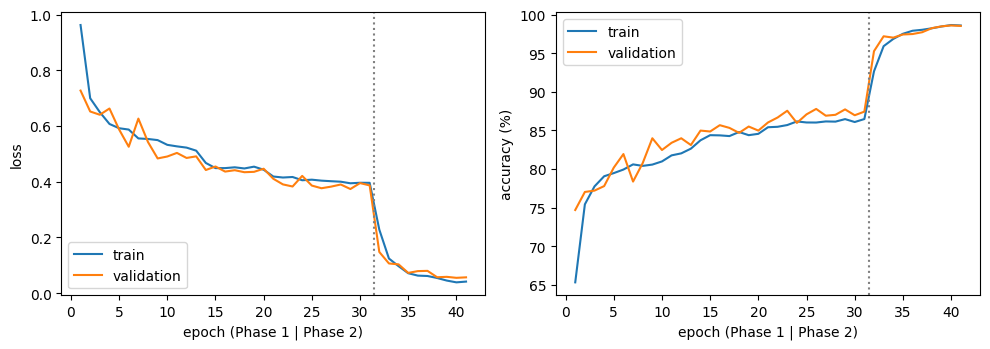

{
 "split": {
  "train": 11963,
  "val": 1710,
  "test": 3419,
  "stratified": true,
  "seed": 42
 },
 "best_val_acc": {
  "phase1": 87.77777777777777,
  "phase2": 98.59649122807018
 },
 "test_accuracy_deterministic": 0.9859608072535829,
 "ece_mc_dropout": 0.003155455407290163,
 "auroc_error_detection": {
  "1 - confidence": 0.9710409980015745,
  "entropy": 0.9703445769999395,
  "variance": 0.9680070247683643
 }
}

Saved: ['split.json', 'skipped_files.json', 'efficientnet_wbc_v2.pt', 'history.json', 'confusion_matrix_v2.png', 'calibration_v2.png', 'training_curves_v2.png', 'summary_v2.json']


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6)); ep = range(1, len(history) + 1); n1 = sum(h['phase'] == 'P1' for h in history)
for a, (tr, va, lab) in zip(ax, [('train_loss', 'val_loss', 'loss'), ('train_acc', 'val_acc', 'accuracy (%)')]):
    a.plot(ep, [h[tr] for h in history], label='train'); a.plot(ep, [h[va] for h in history], label='validation')
    a.axvline(n1 + 0.5, ls=':', color='grey'); a.set_xlabel('epoch (Phase 1 | Phase 2)'); a.set_ylabel(lab); a.legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/training_curves_v2.png', dpi=200); plt.show()

summary = {'split': {'train': len(idx_train), 'val': len(idx_val), 'test': len(idx_test), 'stratified': True, 'seed': SEED},
           'best_val_acc': {'phase1': best1, 'phase2': best2},
           'test_accuracy_deterministic': float(acc1), 'test_accuracy_mc_dropout': float(correct.mean()),
           'macro_f1': report['macro avg']['f1-score'],
           'per_class': {c: {k: report[c][k] for k in ('precision', 'recall', 'f1-score', 'support')} for c in CATEGORIES},
           'ece_deterministic': float(ece_det), 'ece_mc_dropout': float(ece_mc),
           'auroc_error_detection': auroc, 'per_uncertainty_level': per_level, 'n_errors_mc': n_err,
           'thresholds': {'low': [LOW_CONF, LOW_ENT], 'medium': [MED_CONF, MED_ENT]}}
json.dump(summary, open(f'{OUT_DIR}/summary_v2.json', 'w'), indent=1)
print(json.dumps({k: summary[k] for k in ['split', 'best_val_acc', 'test_accuracy_deterministic', 'ece_mc_dropout', 'auroc_error_detection']}, indent=1))
print('\nSaved:', os.listdir(OUT_DIR))

## 7. What to do with the results
* Copy `summary_v2.json`, `confusion_matrix_v2.png`, `calibration_v2.png`, `training_curves_v2.png`, `history.json` and `split.json` into the repo at `results/effnet_v2/`.
* Copy `efficientnet_wbc_v2.pt` into `models/`. To use it in the app, set `models.efficientnet_classification: "models/efficientnet_wbc_v2.pt"` in `config.yaml` (the loader reads the `model_state` key).
* Save this notebook **with outputs** (File → Download → .ipynb) into `Notebooks/Efficientnet_classification/`.
* Expect the test accuracy to be similar to, or slightly below, 99.44 % — a small drop is normal and is the honest number.